# Sesión 1 · Comprensión del problema y EDA inicial
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Roberd Meza Sainz, Saúl Caballero Castor, Andrés Mendez Cortés, Santiago Serrano Montalvo, Sofía Valeria Ramírez Moreno |
| **Fecha** | 19 de agosto del 2026 |
| **Objetivo** | Primera exploración del dataset de House Prices: entender su estructura, identificar el target y detectar problemas iniciales en los datos. |

---

### ¿Cómo descargar el dataset?

1. Ve a [kaggle.com/competitions/house-prices-advanced-regression-techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
2. Acepta las reglas de la competencia (necesitas cuenta de Kaggle).
3. Descarga `train.csv` desde la pestaña **Data**.
4. Colócalo en una carpeta `data/` en este proyecto.

```
tu_proyecto/
├── src/
|   └── sesion1_house_prices.ipynb   ← este archivo
└── data/
    └── train.csv
```

> 📌 **Convención del curso:** usa siempre rutas relativas (`./data/train.csv`), nunca rutas absolutas de tu computadora.

---
## PARTE 1
*Sigue los pasos junto con el profesor. En la Parte 2 trabajarás por tu cuenta.*

### 1.1 Importar librerías y cargar los datos

Importar las herramientas que vamos a usar y cargar el dataset.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset
df = pd.read_csv('../data/train.csv')

print('Dataset cargado correctamente')

Dataset cargado correctamente


### 1.2 ¿Cuántos datos tenemos? → `.shape`

`.shape` devuelve una tupla `(filas, columnas)`. Las filas son observaciones (una casa cada una) y las columnas son variables (características de la casa).

In [54]:
# Dimensiones del dataset: (observaciones, variables)
print('Dimensiones:', df.shape)
print(f'  → {df.shape[0]} casas (filas)')
print(f'  → {df.shape[1]} variables (columnas)')

Dimensiones: (1460, 81)
  → 1460 casas (filas)
  → 81 variables (columnas)


### 1.3 ¿Qué tipos de datos hay? → `.info()`

`.info()` muestra el **tipo de dato** de cada columna y cuántos **valores no nulos** tiene.
Un tipo `object` significa texto; `int64` o `float64` significa numérica.

> Si el conteo de no-nulos de una columna es menor que el total de filas, hay valores faltantes.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 1.4 Estadísticas descriptivas → `.describe()`

`.describe()` resume las columnas **numéricas**: media, desviación estándar, mínimo, máximo y cuartiles (25%, 50%, 75%).

| Estadístico | Qué te dice |
|---|---|
| `mean` | Promedio — puede ser jalado por valores extremos |
| `std` | Qué tan dispersos están los valores |
| `min` / `max` | Rango — útil para detectar valores atípicos |
| `50%` | Mediana — más robusta que la media ante outliers |

In [56]:
# Solo columnas numéricas por defecto
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.5 ¿Hay valores faltantes? → `.isnull().sum()`

`.isnull()` genera un DataFrame de `True`/`False` (True donde hay nulo). `.sum()` los cuenta por columna.

Solo mostramos las columnas que sí tienen faltantes para no perdernos en las que no.

In [57]:
nulos = df.isnull().sum()

# Filtramos solo las columnas con al menos 1 nulo
nulos_presentes = nulos[nulos > 0].sort_values(ascending=False)

print(f'Columnas con valores faltantes: {len(nulos_presentes)}')
print()
print(nulos_presentes.to_string())

Columnas con valores faltantes: 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1


### 1.6 Identificar la variable objetivo (target)

En este dataset el target es `SalePrice` — el precio de venta de la casa.

Veamos cómo se distribuye:

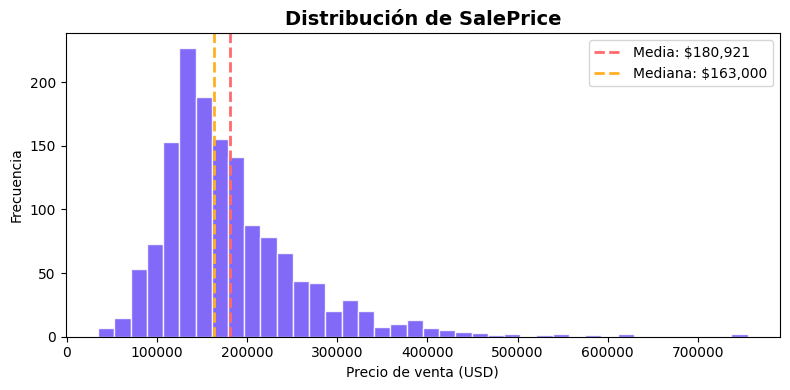

Media:   $     180,921
Mediana: $     163,000
Std:     $      79,443
Mín:     $      34,900
Máx:     $     755,000


In [58]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['SalePrice'], bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2,
           linestyle='--', label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2,
           linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")

ax.set_title('Distribución de SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio de venta (USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Media:   ${df["SalePrice"].mean():>12,.0f}')
print(f'Mediana: ${df["SalePrice"].median():>12,.0f}')
print(f'Std:     ${df["SalePrice"].std():>12,.0f}')
print(f'Mín:     ${df["SalePrice"].min():>12,.0f}')
print(f'Máx:     ${df["SalePrice"].max():>12,.0f}')

La distribución tiene una cola hacia la izquierda (*left skew*). Hay pocas casas muy caras que jalan la media hacia arriba. Por eso la mediana es más baja que la media.

---
## PARTE 2. Reporte de reconocimiento

*A partir de aquí trabajan por su cuenta (en equipo). El objetivo no es solo correr los comandos, es interpretar lo que ven y escribir sus hallazgos en las celdas de texto.*

**Entregable:** este mismo notebook, con todas las celdas ejecutadas y los cuadros de interpretación completados.

> **Documentación oficial de pandas:** [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html)

> Úsenla cuando encuentren un comando que no se explicó en clase.

### 2.1 Primeras y últimas filas: `.head()`, `.tail()`, `.sample()`

Estos tres comandos no se vieron en la presentación, búscalos en la documentación y completa el ejercicio.

| Comando | ¿Qué hace? |
|---|---|
| `df.head(n)` | Muestra las primeras `n` filas (por defecto 5) |
| `df.tail(n)` | Muestra las últimas `n` filas |
| `df.sample(n)` | Muestra `n` filas aleatorias |

In [59]:
# Muestra las primeras 5 filas
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [60]:
# Muestra las últimas 5 filas
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [61]:
# Muestra 5 filas aleatorias (útil para ver muestras representativas)
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
349,350,60,RL,56.0,20431,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,New,Partial,437154
16,17,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
337,338,20,RL,70.0,9135,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,214000
499,500,20,RL,70.0,7535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnWw,Shed,480,6,2007,WD,Normal,120000
986,987,50,RM,59.0,5310,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,117000


**Interpretación:**

*¿Qué tipo de información tienen las primeras columnas? ¿Hay columnas que a primera vista no entiendes qué representan? Anótalas aquí.*

**Las columnas cuentan con la siguiente información: Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice**

**Como equipo, no entendemos las siguientes columnas: MSSubClass, MSZoning, LotFrontage, LotShape, LandContour, Utilities, MiscFeature, MiscVal**

**Nota importante sobre `MSSubClass`: aunque `.info()` la muestra como `int64`, es un código categórico (tipo de vivienda), no una cantidad numérica — hay que revisar `data_description.txt` para no tratarla por error como variable continua en el modelado.**

### 2.2 Tipos de dato y cardinalidad: `.dtypes`, `.nunique()`

`.dtypes` ya lo conocen de `.info()`, pero aquí lo usamos de forma más directa para filtrar variables.
`.nunique()` cuenta cuántos valores únicos tiene cada columna. Es muy útil para detectar columnas casi constantes o IDs disfrazados de variables.

In [62]:
# Valores únicos por columna, de menor a mayor cardinalidad
print(df.nunique().sort_values().to_string())
print()

# Verificamos qué valores toman realmente las columnas de menor cardinalidad
for col in ['CentralAir', 'Utilities', 'Street', 'Alley', 'BsmtHalfBath']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

CentralAir          2
Utilities           2
Street              2
Alley               2
BsmtHalfBath        3
LandSlope           3
GarageFinish        3
HalfBath            3
MasVnrType          3
PavedDrive          3
PoolQC              3
FullBath            4
BsmtExposure        4
ExterQual           4
MiscFeature         4
BsmtFullBath        4
Fence               4
KitchenQual         4
BsmtCond            4
Fireplaces          4
LandContour         4
LotShape            4
KitchenAbvGr        4
BsmtQual            4
FireplaceQu         5
Electrical          5
YrSold              5
GarageCars          5
GarageQual          5
GarageCond          5
HeatingQC           5
ExterCond           5
MSZoning            5
LotConfig           5
BldgType            5
BsmtFinType2        6
Foundation          6
RoofStyle           6
SaleCondition       6
GarageType          6
BsmtFinType1        6
Heating             6
Functional          7
RoofMatl            8
HouseStyle          8
Condition2

**Interpretación:**

*¿Hay columnas con muy pocos valores únicos (por ejemplo, menos de 5)? ¿Qué tipo de variable podría ser esa? ¿Y columnas con un valor único por fila qué significaría eso?*

**Sí, hay muchas columnas con pocos valores únicos. Con el ranking completo (`nunique().sort_values()`) identificamos, entre otras: `Utilities`, `Street`, `CentralAir` y `Alley` (2 valores), `PoolQC`, `MasVnrType`, `LandSlope`, `GarageFinish` (3 valores) y `LotShape`, `Fireplaces`, `FullBath`, `BsmtQual`, `KitchenQual` (4 valores). Verificando algunas con `value_counts()`:**
- CentralAir (Central air conditioning): booleana, toma valores Y/N (no 0/1 como se podría asumir).
- Utilities (Type of utilities available): casi constante, 1459 de 1460 filas son AllPub — aporta poca información al modelo.
- Street (Type of road access): toma valores Pave/Grvl.
- Alley (Type of alley access): toma valores Pave/Grvl o vacío (NaN cuando la casa no tiene acceso por callejón).
- BsmtHalfBath (Basement half bathrooms): variable discreta/ordinal, toma valores 0, 1 o 2.
- Fireplaces y FullBath son variables discretas (conteos), no booleanas: representan cantidad de chimeneas y de baños completos respectivamente.
- LotShape (forma del terreno) es una variable categórica ordinal (Reg, IR1, IR2, IR3).

**La columna con un valor único por fila es `Id`: es un identificador (1460 valores únicos para 1460 filas), no aporta información predictiva y debe excluirse del modelado. En el otro extremo, columnas de cardinalidad alta pero no perfecta como `LotArea`, `GrLivArea` o `1stFlrSF` sí son variables numéricas continuas genuinas, no identificadores.**

### 2.3 Análisis de valores faltantes

El conteo absoluto que vimos en la demo no siempre es suficiente, el porcentaje de faltantes es más informativo para decidir qué hacer con cada columna.

In [63]:
# Porcentaje de valores faltantes por columna
faltantes_pct = ((df.isnull().sum()/df.shape[0])*100).sort_values(ascending=False)
faltantes_pct[faltantes_pct > 0]

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

**Interpretación:**

*¿Cuáles son las 3 columnas con mayor porcentaje de faltantes? Para una de ellas, busca su descripción en el [data_description.txt](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) de Kaggle e intenta entender por qué podría tener tantos faltantes. ¿Es un dato realmente ausente o el faltante tiene un significado?*

**Las 3 columnas con mayor porcentaje de faltantes son:**

- PoolQC (Pool quality): El faltante es debido a que no todas las casas tienen alberca, por lo que las que no tienen no pueden tener este dato.
- MiscFeature (Miscellaneous feature not covered in other categories): Esta columna indica características adicionales de la propiedad que no estan cubiertas por otras columnas como: Ascensor, Segundo garage, etc. Los faltantes son debidos a que no todas las casas tienen características adicionales.
- Alley (Type of alley access): Alley refiere a un tipo de acceso por callejón (pasaje trasero). En el dataset puede tomar el valor de Gravel o Paved, que indica el tipo de suelo que tiene este acceso. En los casos faltantes, son casas que no tienen este callejón de acceso.

**Para varias de estas columnas el faltante es informativo (ausencia de la característica), no un dato realmente perdido. Por eso no conviene imputarlas con la media/moda sin más: es mejor tratarlas como una categoría explícita "None"/"Sin alberca"/"Sin callejón", preservando la información de que la casa carece de esa característica.**

---
## Resumen de hallazgos (conclusión del equipo)

Completen este resumen antes de entregar.

| Pregunta | Respuesta del equipo |
|---|---|
| ¿Cuántas observaciones y variables tiene el dataset? | El dataset cuenta con 1460 observaciones (casas) y 81 variables (80 predictoras + la variable objetivo SalePrice) |
| ¿Cuál es la variable objetivo Y? ¿Define clasificación o regresión? | La variable objetivo es SalePrice. Define un problema de regresión, ya que es una variable numérica continua con un amplio rango de valores posibles, no un conjunto finito de categorías |
| ¿Cuántas columnas tienen valores faltantes? ¿Cuáles son las más críticas? | 19 columnas tienen valores faltantes. Las 3 más críticas son PoolQC (99.5%), MiscFeature (96.3%) y Alley (93.7%); en total, 6 columnas superan el 50% de faltantes: PoolQC, MiscFeature, Alley, Fence, MasVnrType y FireplaceQu |
| ¿Hay algo que les llamó la atención o les generó una pregunta? | Nos llamó la atención que `Utilities` tiene 1459 valores idénticos y solo 1 distinto (puede ser una variable a descartar por no aportar información). También nos sorprendió la cantidad de variables que se usan para describir una sola casa: 81 variables es más de lo que habríamos esperado necesitar |
| ¿Qué tipo de variables (numéricas / categóricas) predominan? | Hay una mezcla: 38 columnas numéricas (`int64`/`float64`) y 43 columnas categóricas (`object`). Muchas de las categóricas describen calidad/condición de distintos elementos de la casa (variables ordinales) |
| ¿Qué observaron sobre la distribución de `SalePrice`? | Tiene sesgo hacia la derecha (cola larga de precios altos): la media (~$180,921) es mayor que la mediana (~$163,000), porque pocas casas muy caras jalan el promedio hacia arriba |
| ¿Qué acciones de limpieza/preprocesamiento anticipan para la siguiente sesión? | Imputar "None" en las columnas donde el faltante significa ausencia de la característica, revisar outliers en `GrLivArea`/`SalePrice`, codificar variables categóricas, y excluir `Id` del modelado |